Importing the Dependencies

In [ ]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

Loading the Dataset

In [ ]:
# Loading the dataset into Pandas dataframe
df = pd.read_csv(r'C:\Users\Vikram\OneDrive\Desktop\Internships\Internship Projects\Future Interns\Task-3.3 Customer dataset.csv')

In [ ]:
# First 5 rows of the dataset
df.head()

,SessionID,UserID,Timestamp,PageType,DeviceType,Country,ReferralSource,TimeOnPage_seconds,ItemsInCart,Purchased
0,session_0,user_2223,2025-01-20 22:53:34,home,Desktop,India,Social Media,55,0,0
1,session_1,user_2192,2025-02-26 12:57:10,home,Tablet,Germany,Email,99,0,0
2,session_1,user_2192,2025-02-26 12:59:11,product_page,Tablet,Germany,Email,121,0,0
3,session_2,user_1708,2025-06-24 15:40:46,home,Mobile,India,Google,160,0,0
4,session_3,user_2976,2025-06-11 07:21:02,home,Tablet,UK,Google,113,0,0


**Data Preprocessing**

In [ ]:
# Total number of rows and columns
df.shape

(12719, 10)

In [ ]:
# Basic information of the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12719 entries, 0 to 12718
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   SessionID           12719 non-null  str  
 1   UserID              12719 non-null  str  
 2   Timestamp           12719 non-null  str  
 3   PageType            12719 non-null  str  
 4   DeviceType          12719 non-null  str  
 5   Country             12719 non-null  str  
 6   ReferralSource      12719 non-null  str  
 7   TimeOnPage_seconds  12719 non-null  int64
 8   ItemsInCart         12719 non-null  int64
 9   Purchased           12719 non-null  int64
dtypes: int64(3), str(7)
memory usage: 993.8 KB


In [ ]:
# Removing unnecessary columns
df = df.drop(columns=['SessionID', 'UserID'])

In [ ]:
df.head()

,Timestamp,PageType,DeviceType,Country,ReferralSource,TimeOnPage_seconds,ItemsInCart,Purchased
0,2025-01-20 22:53:34,home,Desktop,India,Social Media,55,0,0
1,2025-02-26 12:57:10,home,Tablet,Germany,Email,99,0,0
2,2025-02-26 12:59:11,product_page,Tablet,Germany,Email,121,0,0
3,2025-06-24 15:40:46,home,Mobile,India,Google,160,0,0
4,2025-06-11 07:21:02,home,Tablet,UK,Google,113,0,0


In [ ]:
# Converting 'Timestamp' column into Datetime datatype
df['Timestamp'] = pd.to_datetime(df['Timestamp'])


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12719 entries, 0 to 12718
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Timestamp           12719 non-null  datetime64[us]
 1   PageType            12719 non-null  str           
 2   DeviceType          12719 non-null  str           
 3   Country             12719 non-null  str           
 4   ReferralSource      12719 non-null  str           
 5   TimeOnPage_seconds  12719 non-null  int64         
 6   ItemsInCart         12719 non-null  int64         
 7   Purchased           12719 non-null  int64         
dtypes: datetime64[us](1), int64(3), str(4)
memory usage: 795.1 KB


In [ ]:
# Extracting only Year and Month from 'Timestamp' column
df['Timestamp'] = df['Timestamp'].dt.strftime("%Y-%m")

In [ ]:
df.head(3)

,Timestamp,PageType,DeviceType,Country,ReferralSource,TimeOnPage_seconds,ItemsInCart,Purchased
0,2025-01,home,Desktop,India,Social Media,55,0,0
1,2025-02,home,Tablet,Germany,Email,99,0,0
2,2025-02,product_page,Tablet,Germany,Email,121,0,0


**Data Analysis**

Total number of people who purchased and who didn't

In [ ]:
df['Purchased'].value_counts()

Purchased
0    7669
1    5050
Name: count, dtype: int64

- 5,050 people purchased out of total 12,719 people.

List of number of items placed in cart

In [ ]:
df['ItemsInCart'].value_counts().sort_index()

ItemsInCart
0    7906
1     919
2     915
3    1111
4     941
5     927
Name: count, dtype: int64

- Most of the people (7,906) have not placed any item in their cart.

Number of Devices used for visiting the website

In [ ]:
df['DeviceType'].value_counts().sort_values(ascending=False)

DeviceType
Mobile     4256
Desktop    4240
Tablet     4223
Name: count, dtype: int64

- Most of the people have visited the website through their Mobiles.

In [ ]:
df['ReferralSource'].value_counts().sort_values(ascending=False)

ReferralSource
Google          3304
Email           3212
Social Media    3115
Direct          3088
Name: count, dtype: int64

- Most of the people have visited the website through 'Google'.

List of all the people from just visiting the webpage to making payment confirmation

In [ ]:
df['PageType'].value_counts().sort_values(ascending=False)

PageType
home            5000
product_page    3987
cart            1599
checkout        1123
confirmation    1010
Name: count, dtype: int64

- Most of the people have only visited the 'Home' page of the website.
- Very less people have actually made the payment confirmation.

**Relation between 'Device Type' and 'Actual Purchase'**

In [ ]:
df.groupby('DeviceType')['Purchased'].value_counts()

DeviceType  Purchased
Desktop     0            2545
            1            1695
Mobile      0            2571
            1            1685
Tablet      0            2553
            1            1670
Name: count, dtype: int64

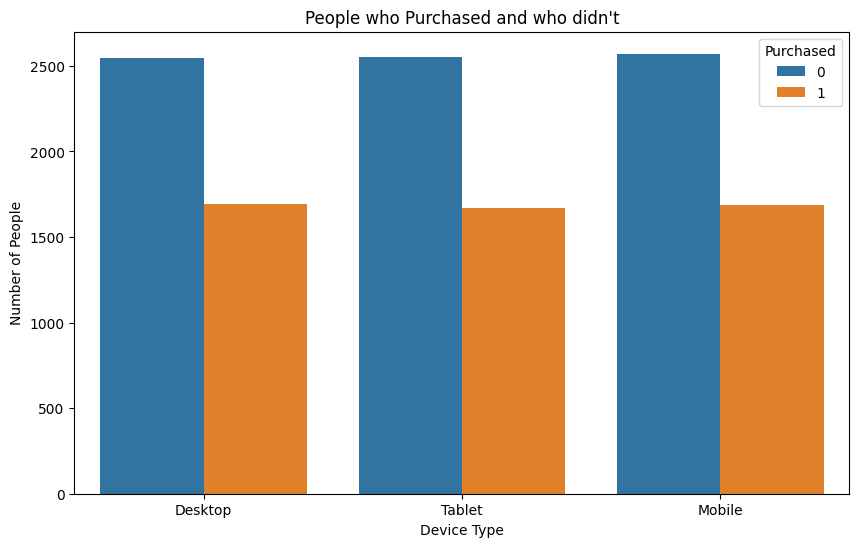

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(x='DeviceType', hue='Purchased', data=df)
plt.xlabel('Device Type')
plt.ylabel('Number of People')
plt.title("People who Purchased and who didn't")

plt.show()

- People who have visited the webpage through 'Desktop' have the maximum purchase, as compared to people visiting from other devices.

**Relation between 'Countries' and 'Actual Purchase'**

In [ ]:
df.groupby('Country')['Purchased'].value_counts()

Country    Purchased
Australia  0            1064
           1             655
Canada     0            1125
           1             700
France     0            1130
           1             850
Germany    0            1078
           1             660
India      0            1069
           1             725
UK         0            1130
           1             725
USA        0            1073
           1             735
Name: count, dtype: int64

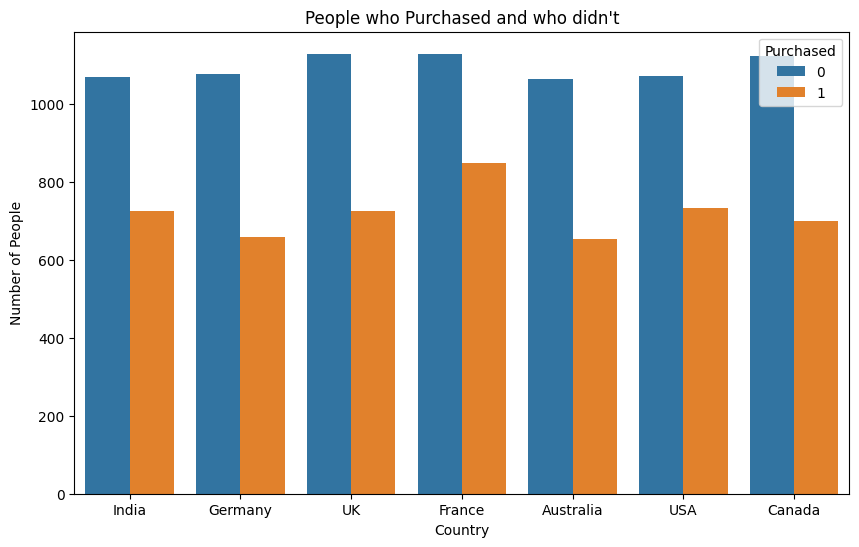

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(x='Country', hue='Purchased', data=df)
plt.xlabel('Country')
plt.ylabel('Number of People')
plt.title("People who Purchased and who didn't")

plt.show()

- People from France who visited the website have the maximum purchase.
- People from Australia who visited the website have the least purchase.

**Relation between 'Referral Source' and 'Actual Purchase'**

In [ ]:
df.groupby('ReferralSource')['Purchased'].value_counts()

ReferralSource  Purchased
Direct          0            1873
                1            1215
Email           0            1957
                1            1255
Google          0            1919
                1            1385
Social Media    0            1920
                1            1195
Name: count, dtype: int64

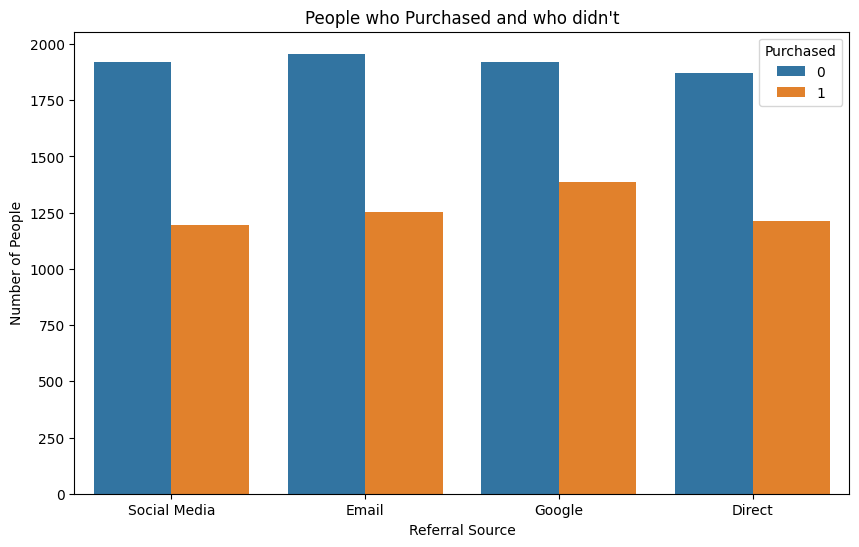

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(x='ReferralSource', hue='Purchased', data=df)
plt.xlabel('Referral Source')
plt.ylabel('Number of People')
plt.title("People who Purchased and who didn't")

plt.show()

- People who were referred by Google have the maximum purchase.

**Relation between 'Items in Cart' and 'Purchase'**

In [ ]:
df.groupby('ItemsInCart')['Purchased'].value_counts()

ItemsInCart  Purchased
0            0            5330
             1            2576
1            1             490
             0             429
2            0             465
             1             450
3            1             605
             0             506
4            1             475
             0             466
5            0             473
             1             454
Name: count, dtype: int64

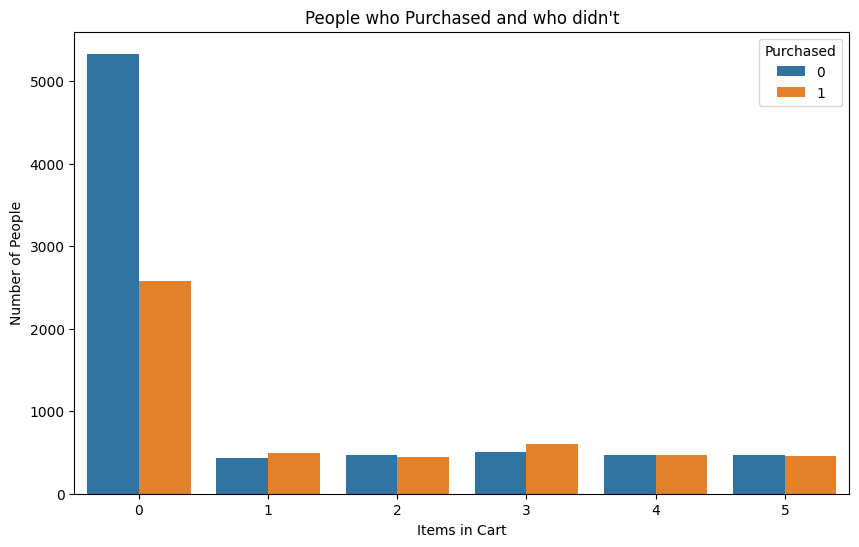

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(x='ItemsInCart', hue='Purchased', data=df)
plt.xlabel('Items in Cart')
plt.ylabel('Number of People')
plt.title("People who Purchased and who didn't")

plt.show()

- People who have not kept any Item in their cart have purchased the maximum (direct purchase).
- People who have kept '2-items' in their cart have purchased the least.

**Purchase made by customers every month**

In [ ]:
df.groupby('Timestamp')['Purchased'].value_counts()

Timestamp  Purchased
2025-01    0            1046
           1             630
2025-02    0             932
           1             550
2025-03    0             947
           1             675
2025-04    0             848
           1             590
2025-05    0             977
           1             645
2025-06    0             968
           1             640
2025-07    0             995
           1             665
2025-08    0             956
           1             655
Name: count, dtype: int64

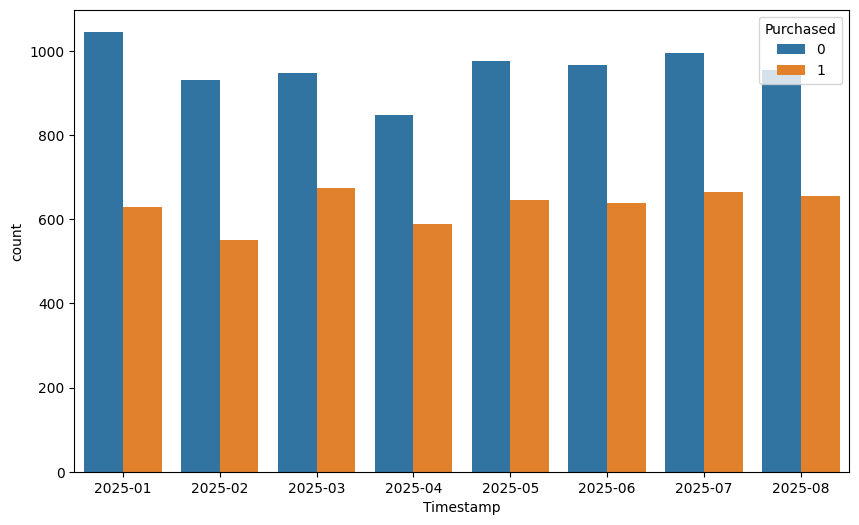

In [ ]:
# Sort dataframe by Timestamp
df = df.sort_values(by='Timestamp')

# Plot
plt.figure(figsize=(10,6))
sns.countplot(x='Timestamp', hue='Purchased', data=df)

plt.show()

- Maximum people purchased in '2025-03' when compared with other months.

**Relation between 'Page Type' and 'Time on Page'**

In [ ]:
time = df.groupby('PageType')['TimeOnPage_seconds'].sum().sort_values(ascending=False).reset_index()
time = pd.DataFrame(time)
time

,PageType,TimeOnPage_seconds
0,home,488954
1,product_page,386967
2,cart,157891
3,checkout,108489
4,confirmation,96882


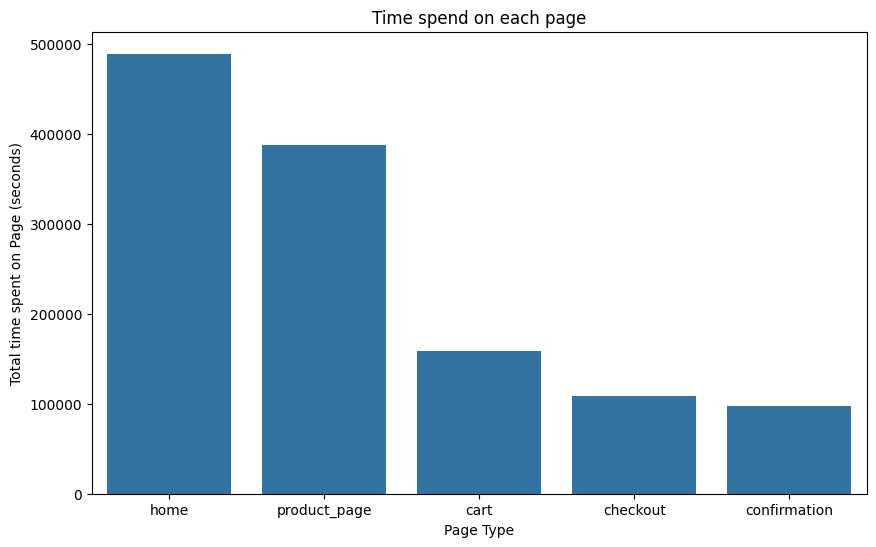

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x='PageType', y='TimeOnPage_seconds', data=time)

plt.xlabel('Page Type')
plt.ylabel('Total time spent on Page (seconds)')
plt.title('Time spend on each page')
plt.show()

- People have spent the most their time on 'Home' page of the website.
- Least time was spent on 'confirmation' page.

**Total time spent on website through each Referral Source**

In [ ]:
refer = df.groupby('ReferralSource')['TimeOnPage_seconds'].sum().sort_values(ascending=False).reset_index()
pd.DataFrame(refer)
refer

,ReferralSource,TimeOnPage_seconds
0,Google,324696
1,Social Media,311067
2,Email,307783
3,Direct,295637


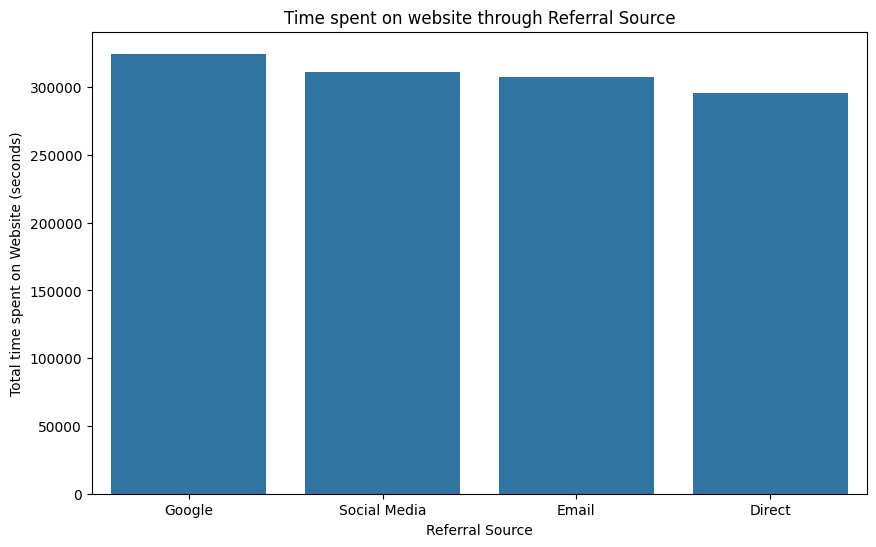

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x=refer['ReferralSource'], y=refer['TimeOnPage_seconds'], data=refer)

plt.xlabel('Referral Source')
plt.ylabel('Total time spent on Website (seconds)')
plt.title('Time spent on website through Referral Source')
plt.show()

- People spent most of the time on the website after being referred by 'Google'.

**Histogram of time spent by people on the website**

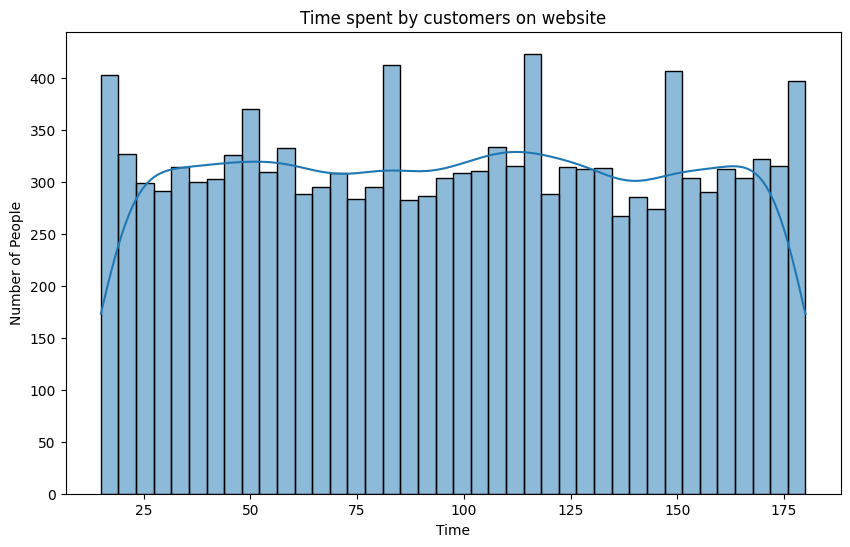

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(df['TimeOnPage_seconds'], bins=40, kde=True)

plt.title('Time spent by customers on website')
plt.xlabel('Time')
plt.ylabel('Number of People')

plt.show()

**Heatmap**

In [ ]:
correlation = df.corr(numeric_only=True)
correlation

,TimeOnPage_seconds,ItemsInCart,Purchased
TimeOnPage_seconds,1.000000,0.004356,-0.007306
ItemsInCart,0.004356,1.000000,0.154557
Purchased,-0.007306,0.154557,1.000000


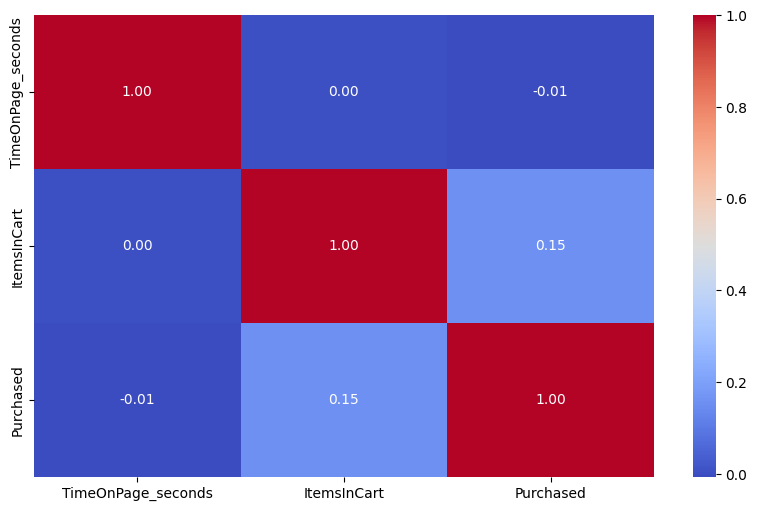

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(correlation, cbar=True, annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

- Customer spending more time on website have Purchased less (or didn't purchase).
- Customers having more Items placed in their Cart have Purchased more.

**Conclusion:**
- Only **5,050 people** purchased any item out of total **12,719 people.**
- Most of the people (7,906) who have visited the website have not placed any item in their cart.
- Most of the people (4,256) have visited the website through their **Mobile Phones.**
- Most of the people (3,304) have visited the website through **Google.**
- Most of the people have only visited the **'Home' page** of the website. Very less people have actually made the payment confirmation.
- People who have visited the webpage through their **'Desktop'** have the maximum purchase.
- People who visited the website from **France** have the maximum purchase.
- People who visited the website from **Australia** have the least purchase.
- People who were referred by **Google** have the maximum purchase (compared to other Referral Sources like - Social Media, Email etc.)
- People who have not kept any Item in their cart have purchased the maximum (direct purchase).
- People who have kept '2-items' in their cart have purchased the least.
- Maximum people purchased in **'2025-03' (675 people)** when compared with other months.
- People have spent the most their time on **'Home' page** of the website.
- Least time was spent on **'confirmation' page.**
- People spent most of the time on the website after being referred by **'Google'.**
- Customer spending more time on website have Purchased less (or didn't purchase).
- Customers having more Items placed in their Cart have Purchased more.

**Recommendations to improve Conversions**

1. **Improve the Website Funnel**
- Improve website navigation and product discovery.
- Reduce the number of steps required for checkout.
- Add personalized product recommendations on the home page.
2. **Optimize Mobile Experience**
- Improve mobile website speed and responsiveness.
- Optimize mobile UI/UX design.
- Add mobile-friendly payment methods.
3. **Reduce Cart Abandonment**
- Offer discounts on first purchase.
- Show "Free Shipping" badges.
- Send cart reminder emails or notifications.
4. **Focus More on Google Marketing**
- Increase investment in: SEO (Search Engine Optimization), Google Ads, Google Shopping Campaigns
- Target high-converting keywords.
- Create blog content to increase organic traffic.
5. **Expand Marketing in Low-Performing Countries**
- Run country-specific advertising campaigns.
- Offer localized discounts and promotions.
- Improve shipping and delivery options in Australia.
6. **Reduce User Confusion on Website**
- Including - Product filtering, Product descriptions, Search functionality
7. **Use Personalized Recommendations**
- Add: "Frequently Bought Together", "Recommended for You", "Customers Also Bought"
- Use AI-based recommendation systems.
8. **Simplify Checkout Process**
- Enable guest checkout.
- Reduce unnecessary form fields.
- Add multiple payment options: UPI, Wallets, Credit/Debit Cards
9. **Analyze High-Sales Months**
- Identify campaigns/offers used during that month.
- Repeat successful seasonal marketing strategies.
- Launch promotional campaigns during similar periods.
10. **Improve Retargeting & Customer Retention**
- Use: Email marketing, Push notifications, Retargeting ads, Personalized offers
- Example: "Complete your purchase and get 10% off!"

**Summary:**
The business should focus on:
- ✅ Improving Mobile Experience
- ✅ Reducing Checkout Friction
- ✅ Increasing Google Marketing
- ✅ Encouraging Cart Additions
- ✅ Retargeting Non-Purchasing Visitors
- ✅ Expanding in Low-Converting Regions
- ✅ Improving Website Navigation & UI/UX

**Expected Outcomes:**
If these recommendations are implemented properly, the business can achieve:
- Higher Conversion Rate
- Increased Customer Retention
- Better User Experience
- Increased Revenue
- Stronger Customer Base
- Reduced Cart Abandonment
- More Returning Customers